In [1]:
import pandas as pd  
import os  
from statsmodels.tsa.seasonal import seasonal_decompose
from local_global import  series_decomp_multi
import torch
import matplotlib.pyplot as plt

folder_path = 'E:/故障诊断/数据集处理/1021/data/cu'  # 替换为你的Excel文件所在的文件夹路径  
all_files = os.listdir(folder_path)  
all_data = []  
  
for file in all_files:  
    if file.endswith('.xlsx'):  # 或者根据你的Excel文件扩展名进行修改  
        df = pd.read_excel(os.path.join(folder_path, file))  
        all_data.append(df)





In [2]:
print(len(all_data))

20


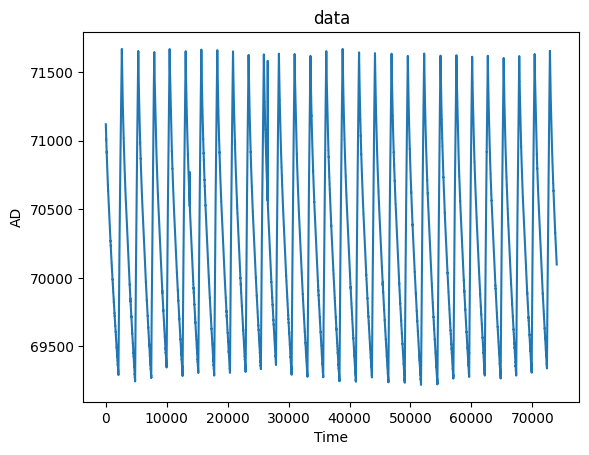

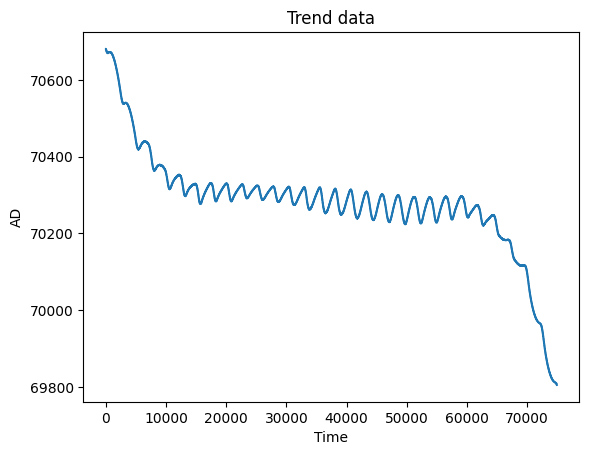

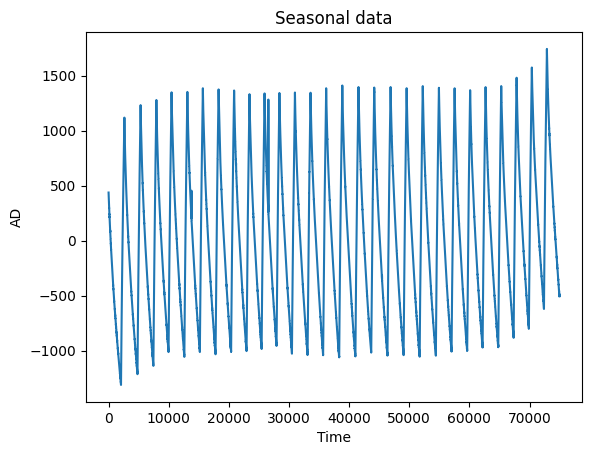

In [8]:
# 创建一个ExcelWriter对象  
writer = pd.ExcelWriter('E:/压力变送器引压管故障诊断/data/output_cu_1001_2001_3001.xlsx', engine='xlsxwriter') 

for i in range(len(all_data)):  
    data = all_data[i]  
    
    # 改变data数据类型为torch.tensor
    lenofdata = len(data)
    data_original = data[:74000]
    data = data.values.reshape(1, lenofdata, 1)
    data = torch.from_numpy(data)
    
    # decomp_multi = series_decomp_multi([1001,2001,3001]) # 多尺度
    # decomp_multi = series_decomp_multi([5001]) # 多尺度
    # decomp_multi = series_decomp_multi([10001]) # 多尺度
    decomp_multi = series_decomp_multi([10001,20001,30001]) # 多尺度
    seasonal_1, trend_1 = decomp_multi(data)
    # result = seasonal_decompose(data, model='additive', period=2000)  # 进行时间序列分解  
    # trend_1 = result.trend
    # seasonal_1 = result.seasonal
    # residual_1 = result.resid
    # 这里你可以将结果保存到数据库、输出到文件或其他操作...
    
    # 改变trend_1 为dataframe
    trend_1 = trend_1.reshape(lenofdata, 1)
    trend_1 = trend_1.detach().numpy()
    trend_1 = pd.DataFrame(trend_1)
    
    # 改变seasonal_1 为dataframe
    seasonal_1 = seasonal_1.reshape(lenofdata, 1)
    seasonal_1 = seasonal_1.detach().numpy()
    seasonal_1 = pd.DataFrame(seasonal_1)

    # 将分解结果保存到Excel工作表中  
    trend_1.to_excel(writer, sheet_name=f'Sheet{i+1}', index=False)  
  
# 保存Excel文件  
writer.close()
plt.plot(data_original)
plt.xlabel('Time')
plt.ylabel('AD')
plt.title('data')

# Show the plot
plt.show()
plt.plot(trend_1)
plt.xlabel('Time')
plt.ylabel('AD')
plt.title('Trend data')

# Show the plot
plt.show()
plt.plot(seasonal_1)
plt.xlabel('Time')
plt.ylabel('AD')
plt.title('Seasonal data')

# Show the plot
plt.show()

c:\Users\zxf\.conda\envs\pytorch\Lib\site-packages\xlsxwriter\workbook.py:368: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


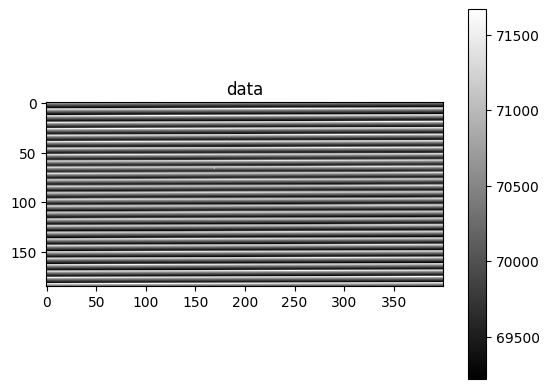

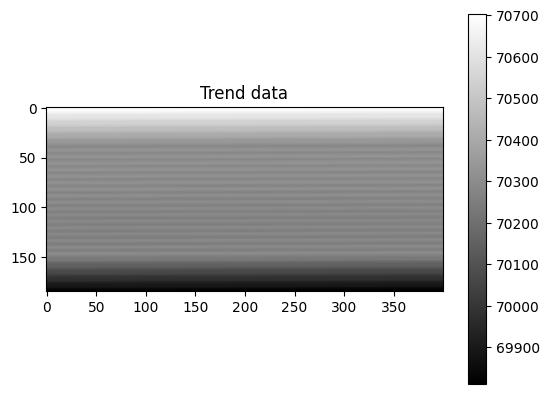

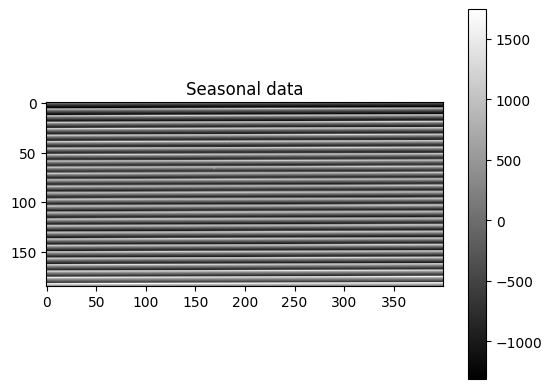

In [10]:
# 时间序列分解后的2维灰度图——成功
# 创建一个ExcelWriter对象  
writer_2D = pd.ExcelWriter('E:/压力变送器引压管故障诊断/data/output_cu_2D.xlsx', engine='xlsxwriter') 
for i in range(len(all_data)):  
    data_1D = all_data[i]  
    
    # 改变data数据类型为torch.tensor
    lenofdata = len(data_1D)
    data_original_1D = data_1D
    data_cut = data_original_1D.iloc[:74000]
    data_2D = data_cut.values.reshape(185,400)

    data_1D = data_1D.values.reshape(1, lenofdata, 1)
    data_1D = torch.from_numpy(data_1D)
    
    # decomp_multi = series_decomp_multi([1001,2001,3001]) # 多尺度
    # decomp_multi = series_decomp_multi([5001]) # 多尺度
    # decomp_multi = series_decomp_multi([10001]) # 多尺度
    # decomp_multi = series_decomp_multi([10001,20001,30001]) # 多尺度
    decomp_multi = series_decomp_multi([30001]) # 多尺度
    seasonal_1D, trend_1D = decomp_multi(data_1D)
    # 改变trend_1 为dataframe
    trend_1D = trend_1D.reshape(lenofdata, 1)
    trend_1D = trend_1D.detach().numpy()
    trend_1D = pd.DataFrame(trend_1D)
    trend_1D_cut = trend_1D.iloc[:74000]
    trend_2D = trend_1D_cut.values.reshape(185,400)
    # 改变seasonal_1 为dataframe
    seasonal_1D = seasonal_1D.reshape(lenofdata, 1)
    seasonal_1D = seasonal_1D.detach().numpy()
    seasonal_1D = pd.DataFrame(seasonal_1)
    seasonal_1D_cut = seasonal_1.iloc[:74000]
    seasonal_2D = seasonal_1D_cut.values.reshape(185,400)

    # 将分解结果保存到Excel工作表中  
    #trend_1_2D.to_excel(writer_2D, sheet_name=f'Sheet{i+1}', index=False)  
  
# 保存Excel文件  
writer.close()

plt.imshow(data_2D, cmap = 'gray')
plt.colorbar()
plt.title('data')

# Show the plot
plt.show()

plt.imshow(trend_2D, cmap = 'gray')
# plt.xlabel('Time')
# plt.ylabel('AD')
plt.colorbar()
plt.title('Trend data')

# Show the plot
plt.show()
plt.imshow(seasonal_2D, cmap = 'gray')
# plt.xlabel('Time')
# plt.ylabel('AD')
plt.colorbar()
plt.title('Seasonal data')

# Show the plot
plt.show()

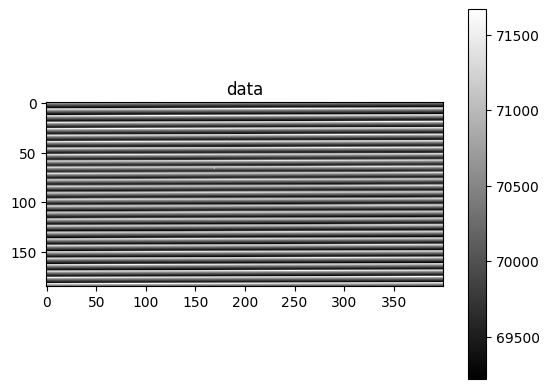

In [13]:
writer_2D = pd.ExcelWriter('E:/压力变送器引压管故障诊断/data/output_xi_2D.xlsx', engine='xlsxwriter') 
for i in range(len(all_data)):  
    data = all_data[i]  
    
    # 改变data数据类型为torch.tensor
    lenofdata = len(data)
    # data = data.values.reshape(1, lenofdata, 1)
    data_cut = data.iloc[:74000]
    data_2D = data_cut.values.reshape(185,400)

plt.imshow(data_2D, cmap = 'gray')
plt.colorbar()
plt.title('data')

# Show the plot
plt.show()